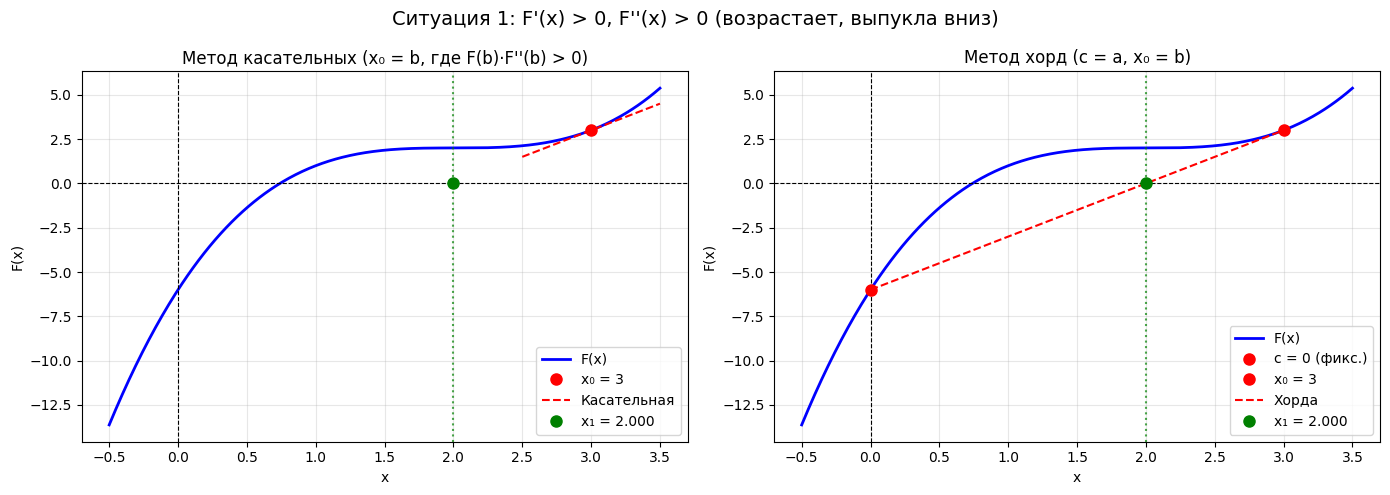

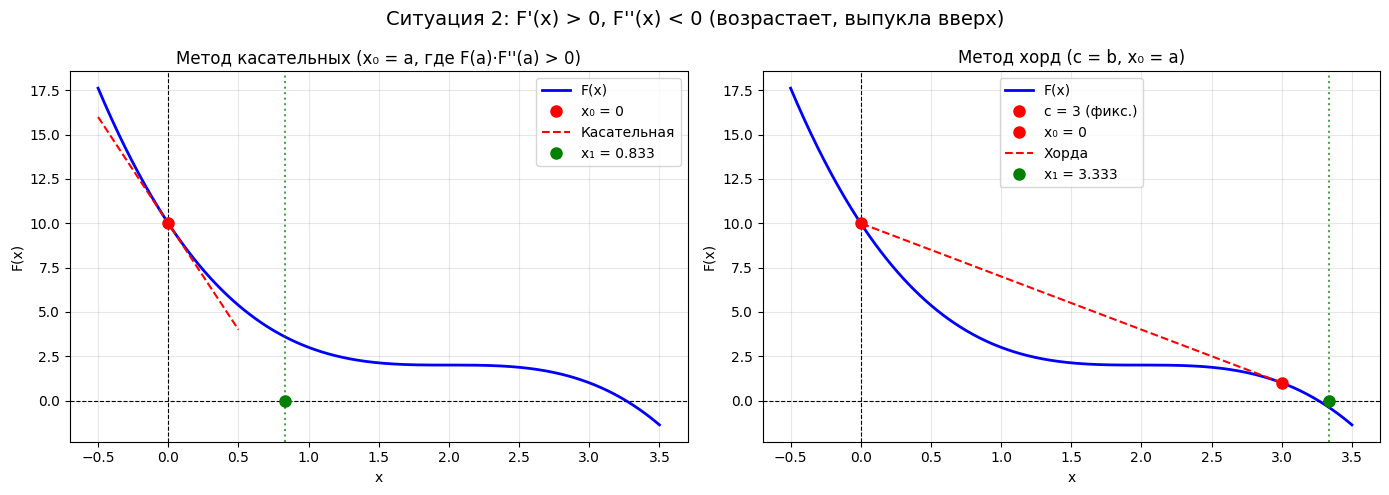

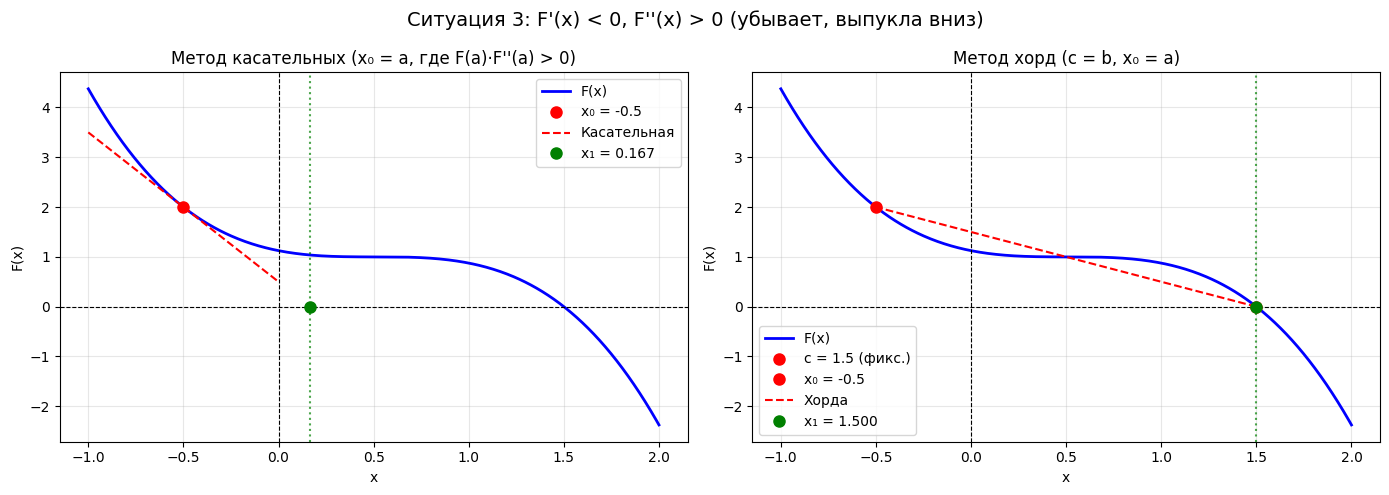

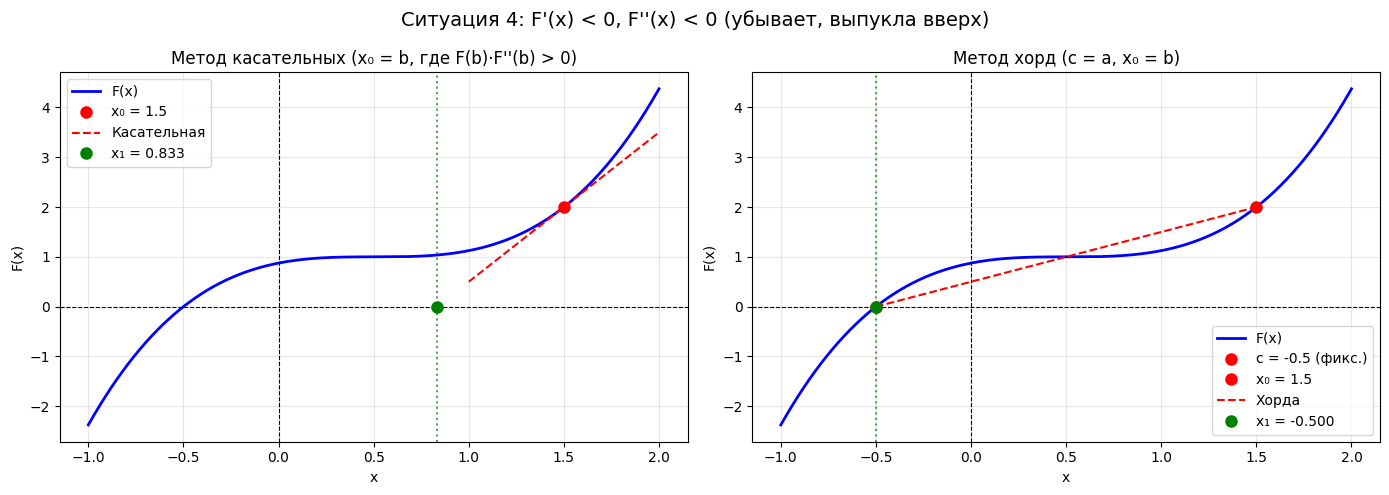

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# Ситуация 1: F'(x) > 0, F''(x) > 0 (возрастает, выпукла вниз)
def f1(x):
    return (x - 2)**3 + 2

def f1_prime(x):
    return 3 * (x - 2)**2

# Ситуация 2: F'(x) > 0, F''(x) < 0 (возрастает, выпукла вверх)
def f2(x):
    return - (x - 2)**3 + 2

def f2_prime(x):
    return -3 * (x - 2)**2

# Ситуация 3: F'(x) < 0, F''(x) > 0 (убывает, выпукла вниз)
def f3(x):
    return - (x - 0.5)**3 + 1

def f3_prime(x):
    return -3 * (x - 0.5)**2

# Ситуация 4: F'(x) < 0, F''(x) < 0 (убывает, выпукла вверх)
def f4(x):
    return (x - 0.5)**3 + 1

def f4_prime(x):
    return 3 * (x - 0.5)**2



def tangent_intersection(f, f_prime, x0):
    """Метод касательных: точка пересечения касательной с осью x"""
    return x0 - f(x0) / f_prime(x0)

def chord_intersection(f, a, b):
    """Метод хорд: точка пересечения хорды с осью x"""
    return a - f(a) * (b - a) / (f(b) - f(a))


def plot_tangent_method(f, f_prime, a, b, x0, title, ax):
    """График для метода касательных"""
    x_vals = np.linspace(a - 0.5, b + 0.5, 500)
    y_vals = f(x_vals)
    
    ax.plot(x_vals, y_vals, 'b-', linewidth=2, label='F(x)')
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.8)
    ax.grid(True, alpha=0.3)
    
    # Начальная точка и касательная
    ax.plot(x0, f(x0), 'ro', markersize=8, label=f'x₀ = {x0}')
    
    x_tan = np.linspace(x0 - 0.5, x0 + 0.5, 100)
    y_tan = f(x0) + f_prime(x0) * (x_tan - x0)
    ax.plot(x_tan, y_tan, 'r--', linewidth=1.5, label='Касательная')
    
    # Следующее приближение
    x1 = tangent_intersection(f, f_prime, x0)
    ax.plot(x1, 0, 'go', markersize=8, label=f'x₁ = {x1:.3f}')
    ax.axvline(x=x1, color='g', linestyle=':', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.legend(loc='best')


def plot_chord_method(f, a, b, c, x0, title, ax):
    """График для метода хорд (c — фиксированный конец, x0 — начальное приближение)"""
    x_vals = np.linspace(min(a, b) - 0.5, max(a, b) + 0.5, 500)
    y_vals = f(x_vals)
    
    ax.plot(x_vals, y_vals, 'b-', linewidth=2, label='F(x)')
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.8)
    ax.grid(True, alpha=0.3)
    
    # Фиксированная точка c и начальное приближение x0
    ax.plot(c, f(c), 'ro', markersize=8, label=f'c = {c} (фикс.)')
    ax.plot(x0, f(x0), 'ro', markersize=8, label=f'x₀ = {x0}')
    
    # Хорда между c и x0
    x_chord = np.linspace(c, x0, 100)
    y_chord = f(c) + (f(x0) - f(c)) * (x_chord - c) / (x0 - c)
    ax.plot(x_chord, y_chord, 'r--', linewidth=1.5, label='Хорда')
    
    # Следующее приближение
    x1 = chord_intersection(f, c, x0)
    ax.plot(x1, 0, 'go', markersize=8, label=f'x₁ = {x1:.3f}')
    ax.axvline(x=x1, color='g', linestyle=':', alpha=0.7)
    
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('F(x)')
    ax.legend(loc='best')

fig1, axes = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle('Ситуация 1: F\'(x) > 0, F\'\'(x) > 0 (возрастает, выпукла вниз)', fontsize=14)

plot_tangent_method(f1, f1_prime, 0, 3, 3, 
                    'Метод касательных (x₀ = b, где F(b)·F\'\'(b) > 0)', axes[0])
plot_chord_method(f1, 0, 3, 0, 3,
                  'Метод хорд (c = a, x₀ = b)', axes[1])

plt.tight_layout()
plt.show()



fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('Ситуация 2: F\'(x) > 0, F\'\'(x) < 0 (возрастает, выпукла вверх)', fontsize=14)

plot_tangent_method(f2, f2_prime, 0, 3, 0,
                    'Метод касательных (x₀ = a, где F(a)·F\'\'(a) > 0)', axes[0])
plot_chord_method(f2, 0, 3, 3, 0,
                  'Метод хорд (c = b, x₀ = a)', axes[1])

plt.tight_layout()
plt.show()



fig3, axes = plt.subplots(1, 2, figsize=(14, 5))
fig3.suptitle('Ситуация 3: F\'(x) < 0, F\'\'(x) > 0 (убывает, выпукла вниз)', fontsize=14)

plot_tangent_method(f3, f3_prime, -0.5, 1.5, -0.5,
                    'Метод касательных (x₀ = a, где F(a)·F\'\'(a) > 0)', axes[0])
plot_chord_method(f3, -0.5, 1.5, 1.5, -0.5,
                  'Метод хорд (c = b, x₀ = a)', axes[1])

plt.tight_layout()
plt.show()



fig4, axes = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle('Ситуация 4: F\'(x) < 0, F\'\'(x) < 0 (убывает, выпукла вверх)', fontsize=14)

plot_tangent_method(f4, f4_prime, -0.5, 1.5, 1.5,
                    'Метод касательных (x₀ = b, где F(b)·F\'\'(b) > 0)', axes[0])
plot_chord_method(f4, -0.5, 1.5, -0.5, 1.5,
                  'Метод хорд (c = a, x₀ = b)', axes[1])

plt.tight_layout()
plt.show()